In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load and prepare data
df = pd.read_csv('train.csv')
df[['day', 'month', 'year']] = df['week'].str.split('/', expand=True)
df = df.drop('week', axis=1)
df = df.drop('record_ID', axis=1)
# df = df[df.units_sold < df.units_sold.quantile(0.99)]  # Remove outliers
df

,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year
0,8091,216418,99.0375,111.8625,0,0,20,17,01,11
1,8091,216419,99.0375,99.0375,0,0,28,17,01,11
2,8091,216425,133.9500,133.9500,0,0,19,17,01,11
3,8091,216233,133.9500,133.9500,0,0,44,17,01,11
4,8091,217390,141.0750,141.0750,0,0,52,17,01,11
...,...,...,...,...,...,...,...,...,...,...
150145,9984,223245,235.8375,235.8375,0,0,38,09,07,13
150146,9984,223153,235.8375,235.8375,0,0,30,09,07,13
150147,9984,245338,357.6750,483.7875,1,1,31,09,07,13
150148,9984,547934,141.7875,191.6625,0,1,12,09,07,13


In [3]:
# Split data
# Lower RMSE here would suggest  product demand is affected by complicated factors — seasonality, store behavior, or product trends.
# --- Features and Target ---
x, y = df.drop('units_sold', axis=1), df['units_sold']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

In [4]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_jobs=-1, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
# rf_r2
print(f"Random Forest RMSE: {rf_rmse:.2f}, R2: {rf_r2:.2f}")

Random Forest RMSE: 26.96, R2: 0.78


In [5]:
# Handle missing values
x_train = x_train.fillna(0)
x_test = x_test.fillna(0)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
# lr_r2
print(f"Linear Regression RMSE: {lr_rmse:.2f}, R2: {lr_r2:.2f}")


Linear Regression RMSE: 48.98, R2: 0.27


In [6]:
# summary statistics of units_sold:
# count: total number of sales records
# mean: average units sold
# std: variation in sales
# min & max: smallest and largest sale amounts
# 25%, 50%, 75%: percentiles see how values are spread
df.units_sold.describe()

count    150150.000000
mean         51.674206
std          60.207904
min           1.000000
25%          20.000000
50%          35.000000
75%          62.000000
max        2876.000000
Name: units_sold, dtype: float64

<Axes: >

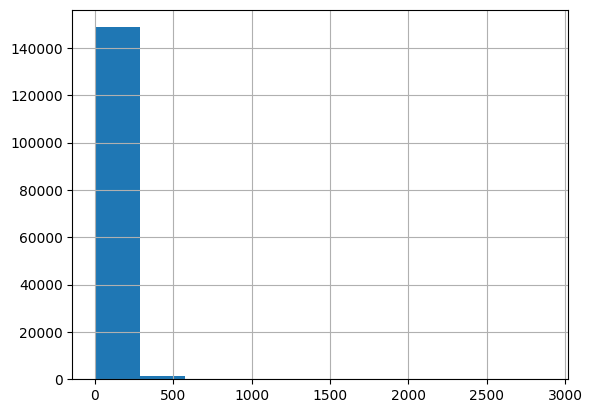

In [7]:
df.units_sold.hist()

In [8]:
# Visualization
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

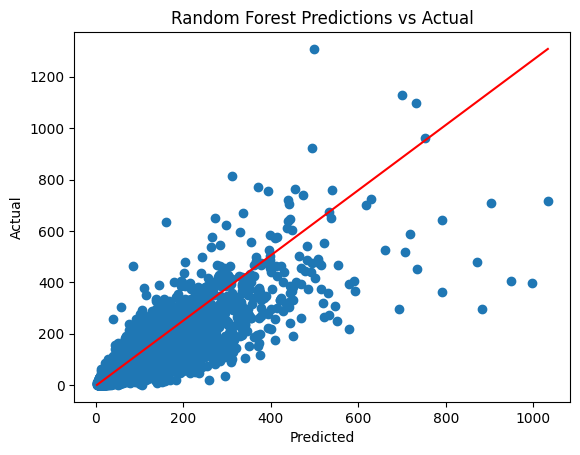

In [9]:
# If the model is good, the dots will be close to the diagonal line — meaning predictions ≈ actuals.
# RF Scatter
plt.scatter(rf_pred, y_test)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.plot(np.linspace(rf_pred.min(), rf_pred.max()), np.linspace(y_test.min(), y_test.max()), color ="red")
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Text(0, 0.5, 'Actual')

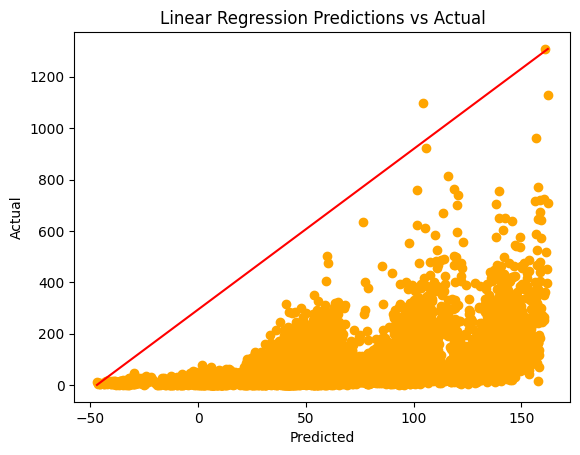

In [10]:
# LR Scatter

plt.scatter(lr_pred, y_test, color='orange')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.plot(np.linspace(lr_pred.min(), lr_pred.max()), np.linspace(y_test.min(), y_test.max()), color ="red")
plt.title("Linear Regression Predictions vs Actual")
plt.xlabel("Predicted")
plt.ylabel("Actual")


In [11]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

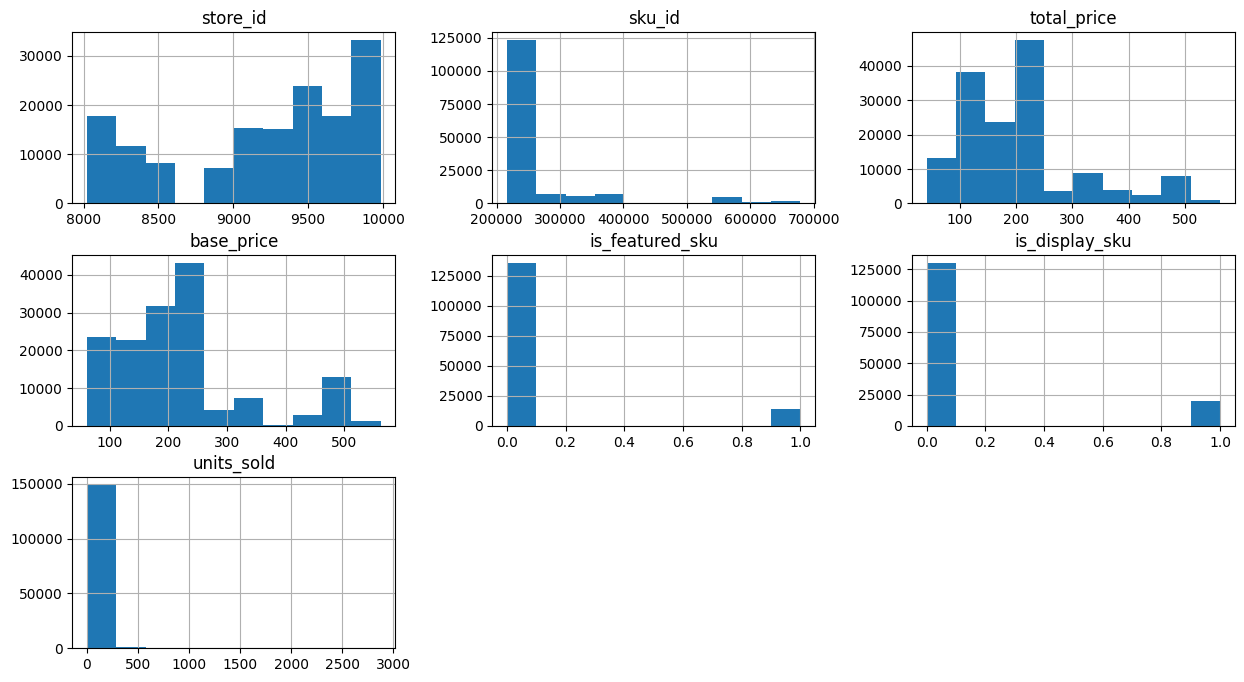

In [12]:
# visual summary of the dataset.
# It helps decide if preprocessing like scaling, log transformation, or removing outliers is needed
# Distribution of each variable (like units_sold, store_id, sku_id, etc.)

# Helps identify: Skewness (is data lopsided?), Outliers (extreme values), Data spread (wide or narrow range)
df.hist(figsize=(15, 8))
plt.show()

In [13]:
len(df.store_id.unique())
len(df.sku_id.unique())
df.units_sold.describe()

count    150150.000000
mean         51.674206
std          60.207904
min           1.000000
25%          20.000000
50%          35.000000
75%          62.000000
max        2876.000000
Name: units_sold, dtype: float64

<Axes: >

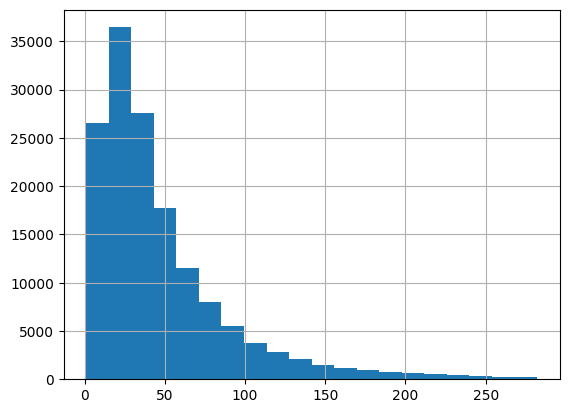

In [14]:
df = df[df.units_sold < df.units_sold.quantile(0.99)]
df.units_sold.hist(bins=20)

In [15]:
x, y = df.drop('units_sold', axis=1), df['units_sold']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_jobs=-1, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
# rf_r2
print(f"Random Forest RMSE: {rf_rmse:.2f}, R2: {rf_r2:.2f}")

Random Forest RMSE: 18.75, R2: 0.81


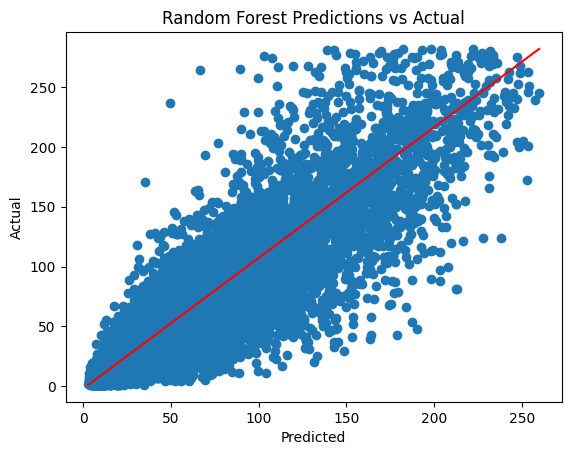

In [17]:
# RF Scatter
plt.scatter(rf_pred, y_test)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.plot(np.linspace(rf_pred.min(), rf_pred.max()), np.linspace(y_test.min(), y_test.max()), color ="red")
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
x, y = df.drop('units_sold', axis=1), df['units_sold']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

In [19]:
# Handle missing values
x_train = x_train.fillna(0)
x_test = x_test.fillna(0)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
# lr_r2
print(f"Linear Regression RMSE: {lr_rmse:.2f}, R2: {lr_r2:.2f}")

Linear Regression RMSE: 36.66, R2: 0.26


Text(0, 0.5, 'Actual')

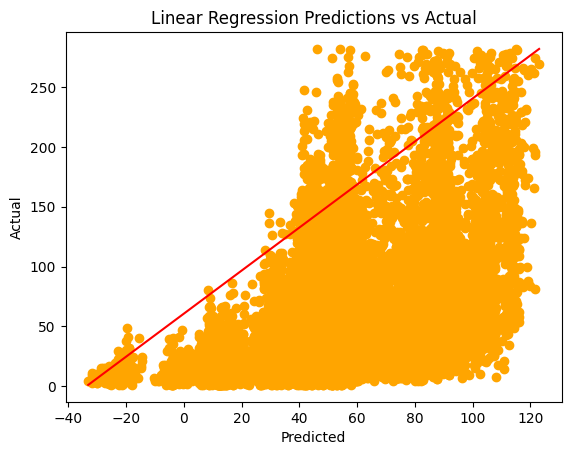

In [20]:
# LR Scatter

plt.scatter(lr_pred, y_test, color='orange')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.plot(np.linspace(lr_pred.min(), lr_pred.max()), np.linspace(y_test.min(), y_test.max()), color ="red")
plt.title("Linear Regression Predictions vs Actual")
plt.xlabel("Predicted")
plt.ylabel("Actual")